# Imputation & Forecasting of time-series using a custom architecture based on CSDI

The implementation uses PyTorch. It is based on the original CSDI implementation, but modified for our needs.

Synthetic data data

In [1]:
!nvidia-smi

Tue Jun 30 11:19:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 4500 Blac...    On  |   00000000:C2:00.0 Off |                  Off |
| 30%   28C    P8              6W /  200W |       2MiB /  32623MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Libraries imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import datetime
import json
import yaml
import os
import sys

# Our code import
sys.path.append("..")
sys.path.append(os.path.abspath("../models"))

from models.custom_main import Custom_CSDI_WaterQual
from utils import *
from dataset_ope import get_dataloader, OPEScaler

In [3]:
# Set seed
rng = np.random.RandomState(1)

## Load Data

In [4]:
#Load all data on GPU, will run on cpu without modification if gpu is not available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, valid_loader, test_loader = get_dataloader('../data/ope_andra/hydrology_sagd_training_data_50_hte.csv',
                                                         path_covariate_data='../data/ope_andra/safran_covariates.csv',
                                                         device=device,
                                                         batch_size=8)



Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


In [5]:
# Load complementary info for titles and dates...

dates_data, sagd_parameters_data = load_meta_data()

In [6]:
scaler = OPEScaler(train_loader, device)

## Model Definition and Training

In [7]:
data_dim = 75

In [8]:
# Load the config

# My own config for cigeo
path = "../config/water_quality_imputation.yaml"

with open(path, "r") as f:
    config = yaml.safe_load(f)

# The only thing I overwrite, so I can change epochs for my tests
config["train"]["epochs"] = 100

current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S") 
foldername = (
    "./save/validationindex" + "_" + current_time
)

os.makedirs(foldername, exist_ok=True)
with open(foldername + "config.json", "w") as f:
    json.dump(config, f, indent=4)


In [9]:
from models.custom_main import Custom_CSDI_WaterQual

model = Custom_CSDI_WaterQual(config, device, target_dim=data_dim).to(device)

/workspace/last_last_version/notebooks/../models/custom_architecture.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=layers)


In [10]:
do_train = False

if do_train:
# define and train mode. keep an history for monitoring
    history  = {}

    # It returns history, which we don't need really
    _ = train(
        model,
        config["train"],
        train_loader,
        valid_loader=valid_loader,
        history=history)

In [ ]:
if do_train:
    torch.save(model.state_dict(), "../saved_weights/custom_model_weights.pt")
else:
    if torch.cuda.is_available():
        model.load_state_dict(torch.load("../saved_weights/custom_model_weights.pt", weights_only=True))
    else : model.load_state_dict(torch.load("../saved_weights/custom_model_weights.pt", weights_only=True, map_location=device))
model.to(device)

In [12]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))


model size: 4.934MB


## Evaluations and Tests

### Single generation test

In [13]:
from utils import plot_single_imputation_results

In [14]:
# Load next batch manually
batch = next(iter(test_loader))

device = model.device
observed_mask = batch['observed_mask'].to(device, dtype=torch.float32)
observed_data = batch['observed_data'].to(device, dtype=torch.float32)
timestamps = batch['timepoints'].to(device)  # Souvent nécessaire pour le modèle

observed_mask_forecast = observed_mask.clone()
observed_mask_forecast[:, 25:] = 0.

observed_data_masked = observed_data * observed_mask_forecast

# GENERATE WITH MODEL
generated = model.impute(
    observed_data_masked, 
    observed_mask_forecast, 
    n_samples=1, 
    timestamps=timestamps
)

/workspace/last_last_version/notebooks/../models/custom_main.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  observed_tp = torch.tensor(observed_tp, dtype=torch.float32).to(self.device)
/workspace/last_last_version/notebooks/../models/custom_main.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  alphas = position.new_tensor(cycles)                  # (C,)


In [15]:
scaler = OPEScaler(train_loader, device)

scaled_generated = scaler.scale_back(generated)

In [16]:
# Bring back the data on the cpu for vizualization

generated_test = scaled_generated.cpu().permute([0, 1, 3, 2]).numpy()[0].squeeze()
observations = observed_data[0].squeeze().cpu().numpy()
mask = observed_mask_forecast[0].squeeze().cpu().numpy()
timestamps = batch['timepoints'][0].squeeze().numpy()

generated_test.shape, observations.shape, mask.shape, timestamps.shape

((24, 75), (24, 75), (24, 75), (24,))

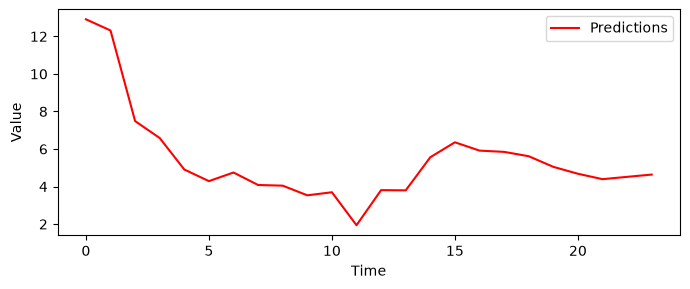

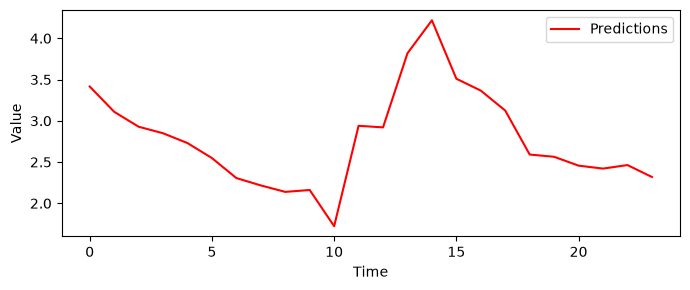

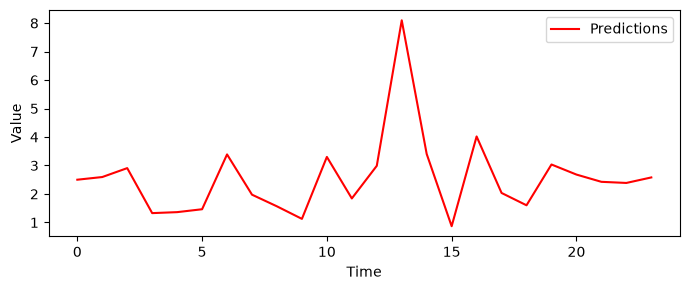

In [17]:
plot_single_imputation_results(generated_test, mask)

## Evaluate Forecasting

### Forecasting Metrics

In [18]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            model,
            test_loader,
            prediction_horizon=h,
            nsample=100,
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std over triales
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 4/4 [03:17<00:00, 49.30s/it, rmse_total=0.461, mae_total=0.159, smape_total=27.7, batch_no=4]


Trial 2/5


100%|██████████| 4/4 [03:34<00:00, 53.72s/it, rmse_total=0.461, mae_total=0.158, smape_total=27.6, batch_no=4]


Trial 3/5


...

Trial 4/5


100%|██████████| 4/4 [03:39<00:00, 54.83s/it, rmse_total=0.461, mae_total=0.158, smape_total=27.5, batch_no=4]


Trial 5/5


100%|██████████| 4/4 [03:28<00:00, 52.22s/it, rmse_total=0.461, mae_total=0.158, smape_total=27.5, batch_no=4]



=== Forecasting Results ===

Horizon: 6
rmse: 0.3179 ± 0.0014
mae: 0.0827 ± 0.0003
smape: 17.0253 ± 0.0656
CRPS: 0.0782 ± 0.0005
CRPS_sum: 0.0561 ± 0.0001

Horizon: 12
rmse: 0.3962 ± 0.0009
mae: 0.1180 ± 0.0002
smape: 22.1744 ± 0.0947
CRPS: 0.1109 ± 0.0004
CRPS_sum: 0.0872 ± 0.0002

Horizon: 18
rmse: 0.4608 ± 0.0005
mae: 0.1582 ± 0.0003
smape: 27.5558 ± 0.0594
CRPS: 0.1473 ± 0.0003
CRPS_sum: 0.1356 ± 0.0001


### Forecasting Visualization

In [19]:
batch = next(iter(test_loader))

device = model.device
observed_mask = batch['observed_mask'].to(device, dtype=torch.float32)
real_data = batch['observed_data'].to(device, dtype=torch.float32)
timestamps = batch['timepoints'].to(device)  # Souvent nécessaire pour le modèle

observed_mask_forecast = observed_mask.clone()
observed_mask_forecast[:, 18:] = 0.

observed_data_masked = observed_data * observed_mask_forecast

# GENERATE WITH MODEL
generated = model.impute(real_data, observed_mask_forecast, n_samples=30, timestamps=batch['timepoints'])


In [20]:
scaled_generated = scaler.scale_back(generated)
scaled_real_data = scaler.scale_back(real_data.transpose(2 ,1)).transpose(2 ,1)

In [21]:
def multivariate_visualize(dataind, generated, real_data, observed_mask, observed_mask_forecast, parameter_names=None):
    """
    Preprocesses the model outputs and generates the multi-variate visualization grid.
    """
    # --- 1. Vectorized Data Preprocessing ---
    # Permute and move to CPU once
    generated_test = generated.permute(0, 1, 3, 2).cpu()
    
    all_target_np = real_data.cpu()
    all_given_np = observed_mask_forecast.cpu()
    all_evalpoint_np = observed_mask.cpu() - all_given_np
    
    K = generated_test.shape[-1]  # Features / Channels
    L = generated_test.shape[-2]  # Time length

    # Vectorized Quantile Calculation: Pass the entire list of quantiles at once
    q_tensor = torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95])
    # Shape of quantiles_imp will be [5, batch, time, features]
    quantiles_imp = torch.quantile(generated_test, q_tensor, dim=1)
    
    # Broadcast the imputation formula across all quantiles at once
    # (1 - all_given_np) broadcasts perfectly over the quantile dimension
    quantiles_imp = quantiles_imp * (1 - all_given_np) + all_target_np * all_given_np

    # --- 2. Plotting Logic ---
    plt.rcParams["font.size"] = 16
    fig, axes = plt.subplots(nrows=9, ncols=9, figsize=(30.0, 20.0))
    fig.delaxes(axes[-1][-1])  # Remove the 81st subplot to keep a 9x9 layout clear

    time_steps = np.arange(0, L)

    for k in range(K):
        row, col = k // 9, k % 9
        ax = axes[row][col]

        # Extract target slices for the specific sample and feature
        target_slice = all_target_np[dataind, :, k]
        eval_slice = all_evalpoint_np[dataind, :, k]
        given_slice = all_given_np[dataind, :, k]

        # Use clean boolean masking instead of creating and filtering heavy DataFrames
        eval_mask = eval_slice != 0
        given_mask = given_slice != 0

        # Plot CSDI Median (Index 2 corresponds to 0.50 quantile) and Confidence Bounds
        ax.plot(time_steps, quantiles_imp[2, dataind, :, k], color='g', label='CSDI')
        ax.fill_between(time_steps, quantiles_imp[0, dataind, :, k], quantiles_imp[4, dataind, :, k], color='g', alpha=0.3)

        # Plot actual observations (blue dots for evaluation points, red x's for given points)
        ax.plot(time_steps[eval_mask], target_slice[eval_mask], color='b', marker='o', linestyle='None')
        ax.plot(time_steps[given_mask], target_slice[given_mask], color='r', marker='x', linestyle='None')

        if parameter_names is not None and k < len(parameter_names):
            ax.set_title(f"{parameter_names[k]}")
        elif parameter_names and k < len(parameter_names):
            ax.set_title(parameter_names[k])

        # Clean axis labels
        if col == 0:
            ax.set_ylabel('value')
        if row == 8: 
            ax.set_xlabel('time')

    plt.tight_layout()
    return fig, axes

(<Figure size 3000x2000 with 80 Axes>,
 array([[<Axes: title={'center': 'OPE90011_CHL'}, ylabel='value'>,
         <Axes: title={'center': 'OPE90012_CHL'}>,
         <Axes: title={'center': 'OPE90013_CHL'}>,
         <Axes: title={'center': 'OPE90014_CHL'}>,
         <Axes: title={'center': 'OPE90015_CHL'}>,
         <Axes: title={'center': 'EST3012_CL'}>,
         <Axes: title={'center': 'OPE90011_CL'}>,
         <Axes: title={'center': 'OPE90012_CL'}>,
         <Axes: title={'center': 'OPE90013_CL'}>],
        [<Axes: title={'center': 'OPE90014_CL'}, ylabel='value'>,
         <Axes: title={'center': 'OPE90015_CL'}>,
         <Axes: title={'center': 'EST3012_COD'}>,
         <Axes: title={'center': 'OPE90011_COD'}>,
         <Axes: title={'center': 'OPE90012_COD'}>,
         <Axes: title={'center': 'OPE90013_COD'}>,
         <Axes: title={'center': 'OPE90014_COD'}>,
         <Axes: title={'center': 'OPE90015_COD'}>,
         <Axes: title={'center': 'OPE90011_CYA'}>],
        [<Axes: t

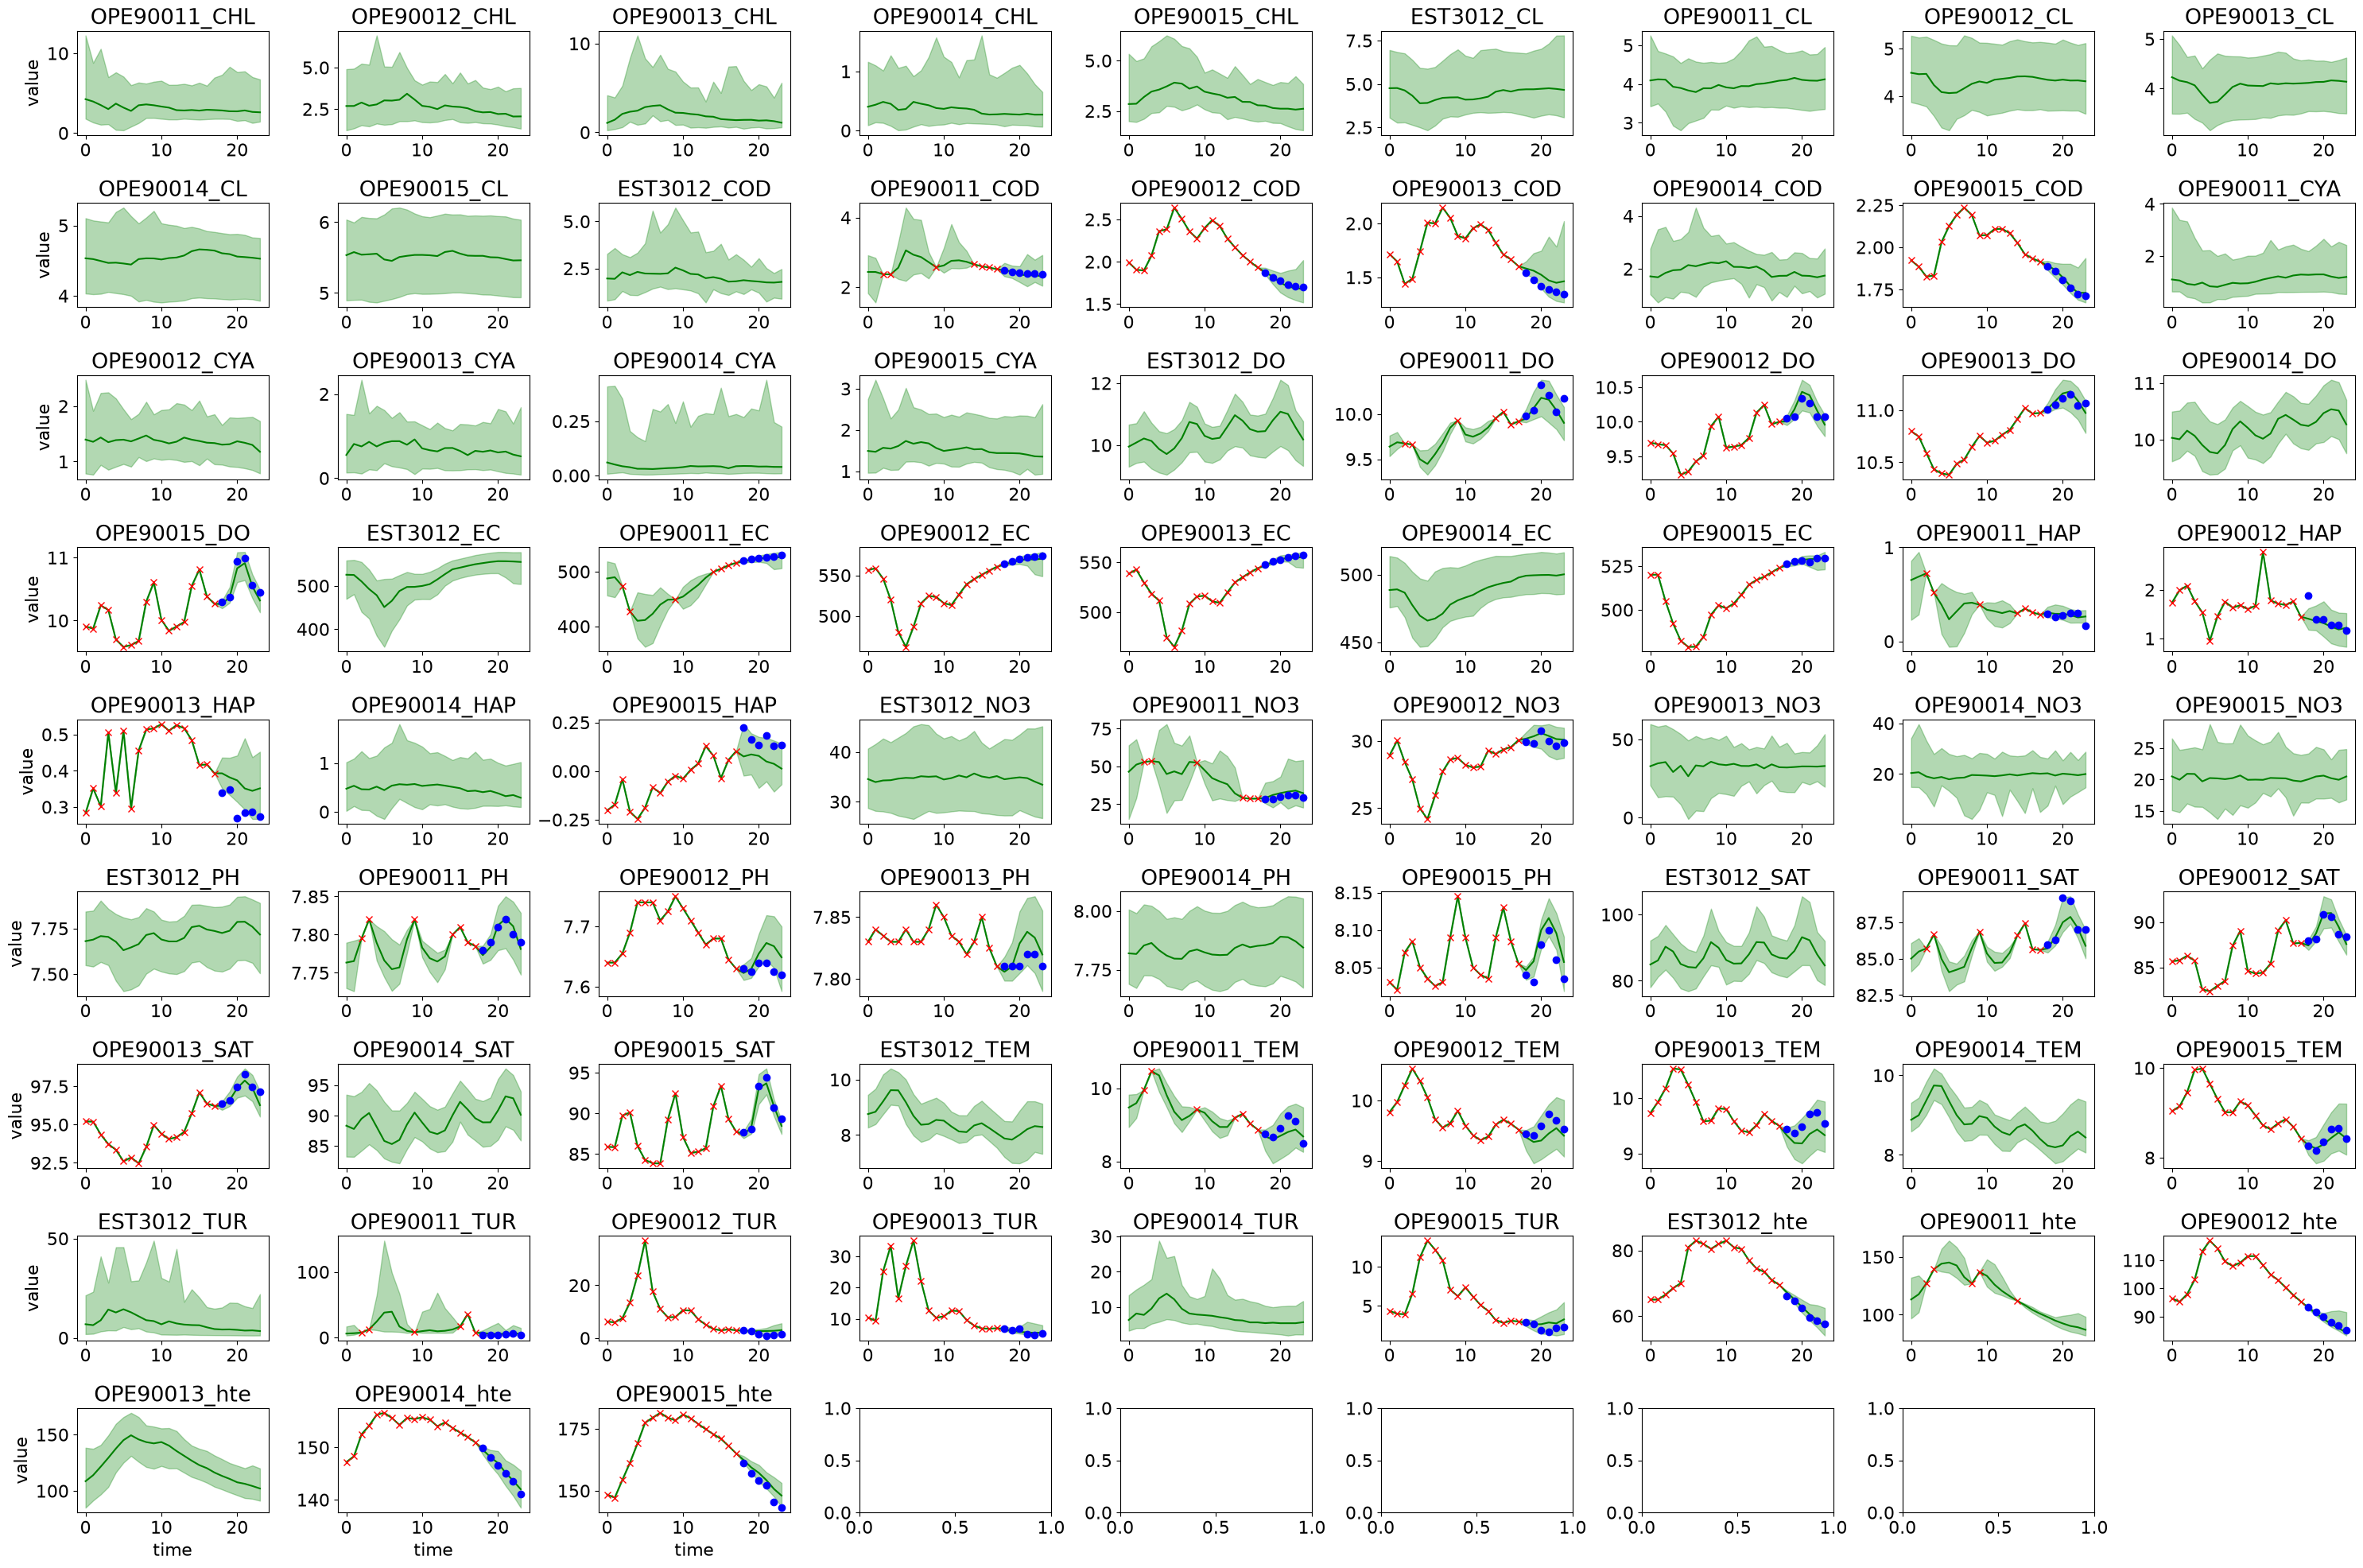

In [22]:
dataind = 4 # Modify to visualize a different realization
multivariate_visualize(dataind, scaled_generated, scaled_real_data, observed_mask, observed_mask_forecast, sagd_parameters_data)

## Evaluate Imputation

### Imputation Metrics

In [ ]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std over trials
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

### Imputation Visualization

In [25]:
# We only need one batch, so fetch it directly without a full loop
batch = next(iter(test_loader))

observed_mask = batch['observed_mask']
real_data = batch['observed_data']

# Calculate exact number of timesteps to retain
ratio_to_keep = 0.45  # 55% missing
num_timesteps = observed_mask.shape[1]
timesteps_to_keep = int(ratio_to_keep * num_timesteps)

# Vectorized random masking: Generate random noise matching the time and channel dimensions
# & find the threshold value for each channel to keep exactly the top 'timesteps_to_keep'
noise = torch.rand(observed_mask.shape[1], observed_mask.shape[2], device=observed_mask.device)
thresholds = torch.topk(noise, k=timesteps_to_keep, dim=0).values[-1, :]

# Create the imputation mask entirely in PyTorch
random_mask = noise >= thresholds
observed_mask_imputation = observed_mask * random_mask.unsqueeze(0)

# Prepare inputs for the model
observed_data = real_data * observed_mask_imputation

observed_mask_imputation = observed_mask_imputation.to(model.device).float()
observed_data = observed_data.to(model.device).float()

# Inference
# GENERATE WITH MODEL
generated = model.impute(
    observed_data, 
    observed_mask_imputation, 
    n_samples=30, 
    timestamps=batch['timepoints']
)
scaled_generated = scaler.scale_back(generated)

In [26]:
scaled_generated = scaler.scale_back(generated)
scaled_real_data = scaler.scale_back(real_data.transpose(2 ,1).to(device)).transpose(2 ,1)

(<Figure size 3000x2000 with 80 Axes>,
 array([[<Axes: title={'center': 'OPE90011_CHL'}, ylabel='value'>,
         <Axes: title={'center': 'OPE90012_CHL'}>,
         <Axes: title={'center': 'OPE90013_CHL'}>,
         <Axes: title={'center': 'OPE90014_CHL'}>,
         <Axes: title={'center': 'OPE90015_CHL'}>,
         <Axes: title={'center': 'EST3012_CL'}>,
         <Axes: title={'center': 'OPE90011_CL'}>,
         <Axes: title={'center': 'OPE90012_CL'}>,
         <Axes: title={'center': 'OPE90013_CL'}>],
        [<Axes: title={'center': 'OPE90014_CL'}, ylabel='value'>,
         <Axes: title={'center': 'OPE90015_CL'}>,
         <Axes: title={'center': 'EST3012_COD'}>,
         <Axes: title={'center': 'OPE90011_COD'}>,
         <Axes: title={'center': 'OPE90012_COD'}>,
         <Axes: title={'center': 'OPE90013_COD'}>,
         <Axes: title={'center': 'OPE90014_COD'}>,
         <Axes: title={'center': 'OPE90015_COD'}>,
         <Axes: title={'center': 'OPE90011_CYA'}>],
        [<Axes: t

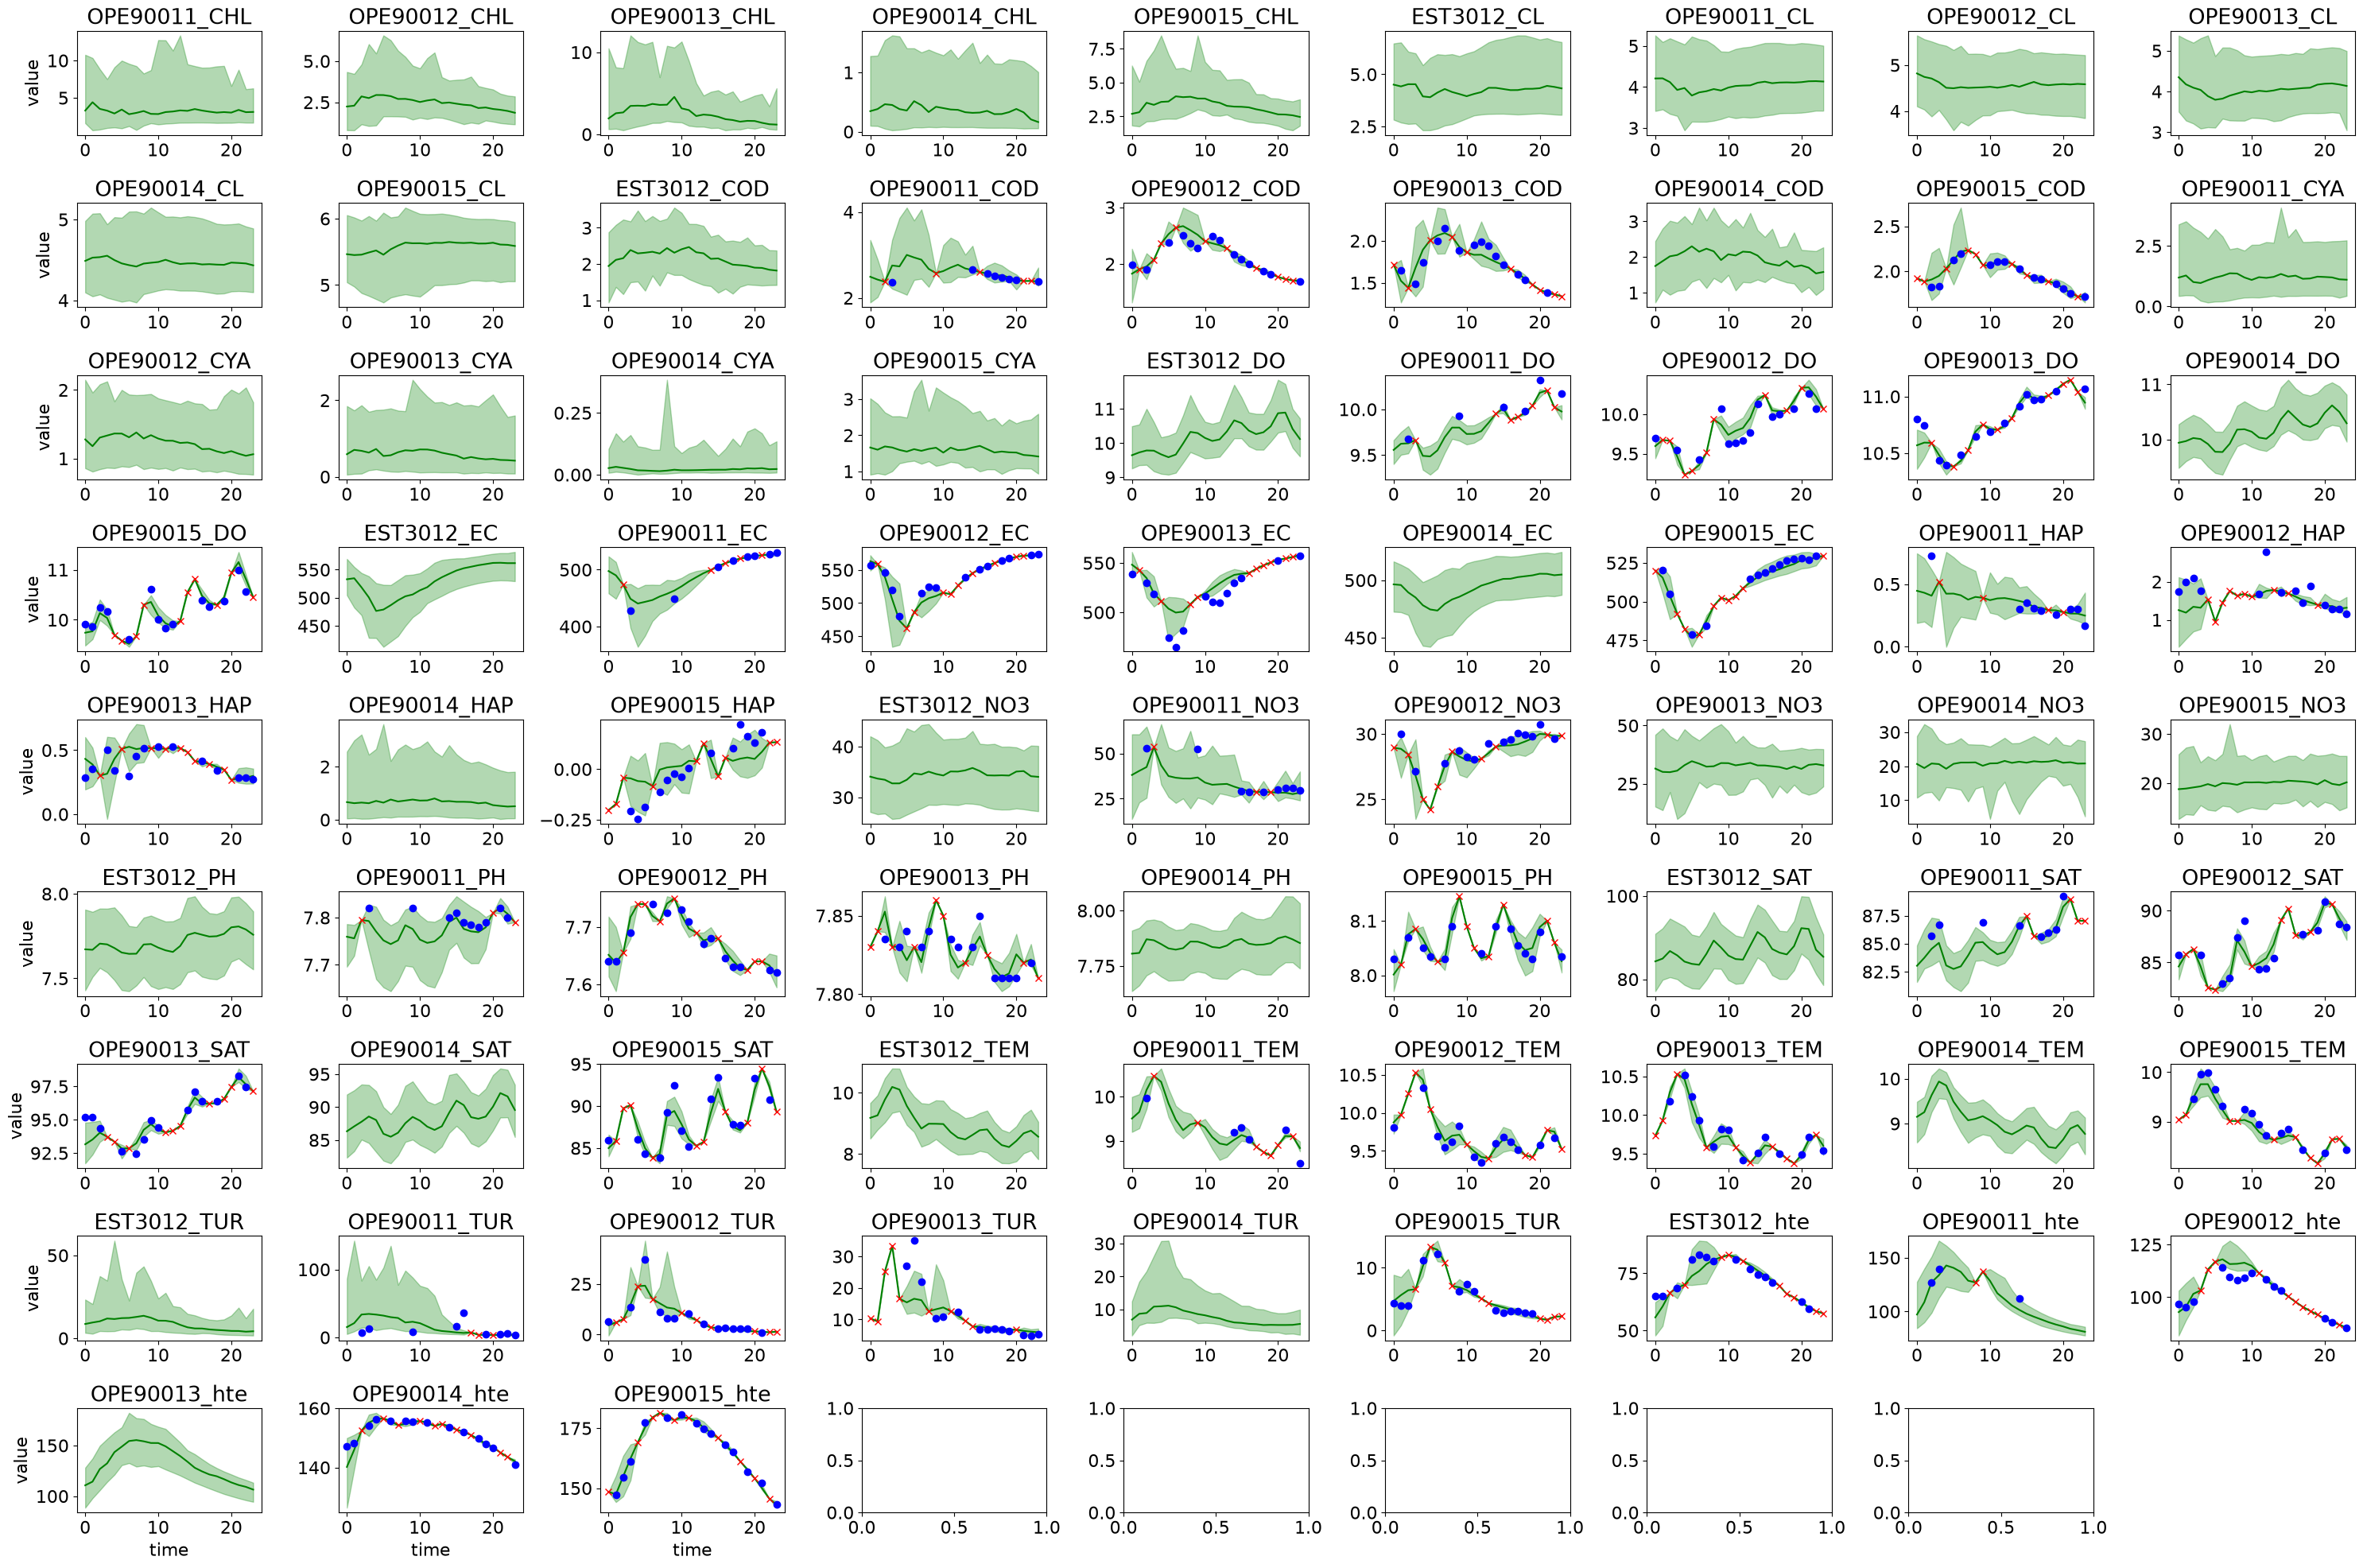

In [27]:
multivariate_visualize(dataind, scaled_generated, scaled_real_data, observed_mask, observed_mask_imputation, sagd_parameters_data)